In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score
import joblib
import sklearn
import pickle

In [2]:
df=pd.read_csv("creditcard.csv.zip")

In [83]:
print("nupmy_Version",np.__version__)
print ("Pandas_Version" , pd.__version__)
print ("sklearn " , sklearn.__version__)

nupmy_Version 2.4.4
Pandas_Version 3.0.2
sklearn  1.8.0


In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

<Axes: xlabel='Class', ylabel='count'>

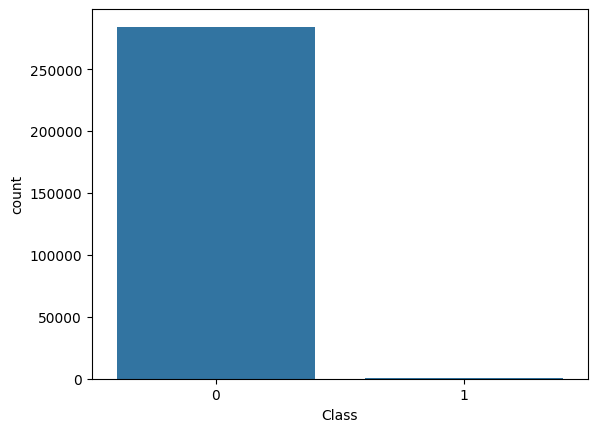

In [15]:
sns.countplot(x='Class',data=df)

In [17]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [18]:
df.skew()

Time      -0.035568
V1        -3.280667
V2        -4.624866
V3        -2.240155
V4         0.676292
V5        -2.425901
V6         1.826581
V7         2.553907
V8        -8.521944
V9         0.554680
V10        1.187141
V11        0.356506
V12       -2.278401
V13        0.065233
V14       -1.995176
V15       -0.308423
V16       -1.100966
V17       -3.844914
V18       -0.259880
V19        0.109192
V20       -2.037155
V21        3.592991
V22       -0.213258
V23       -5.875140
V24       -0.552499
V25       -0.415793
V26        0.576693
V27       -1.170209
V28       11.192091
Amount    16.977724
Class     23.997579
dtype: float64

In [20]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


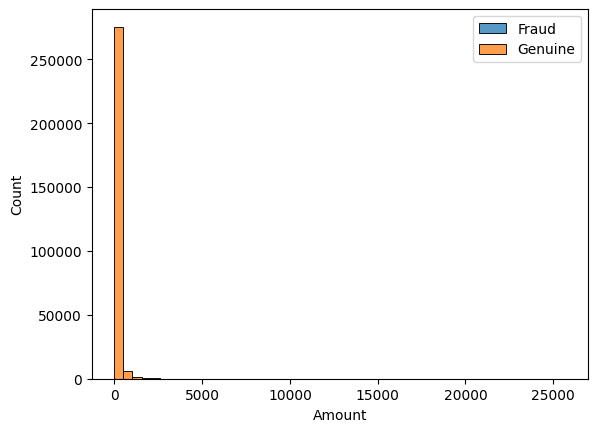

In [3]:
sns.histplot(df[df['Class']== 1]['Amount'] ,bins = 50 , label = 'Fraud')
sns.histplot(df[df['Class']== 0]['Amount'] , bins = 50 , label = 'Genuine')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Genuine wala Scale')

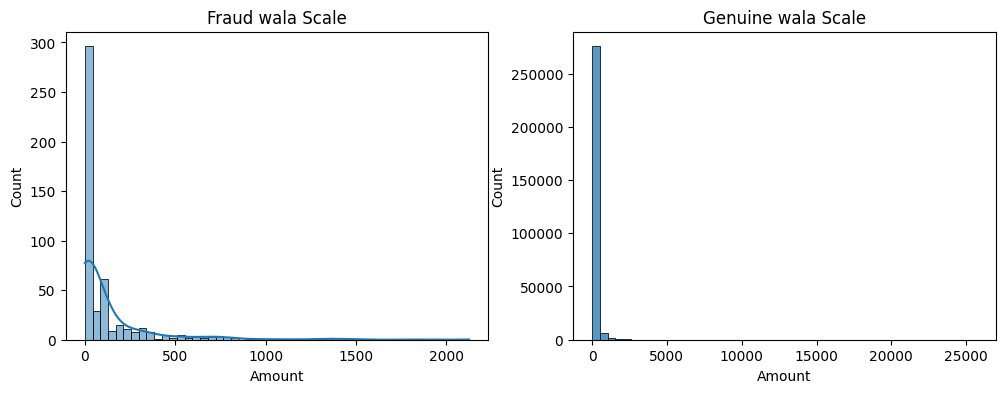

In [35]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df[df['Class']==1]['Amount']  , bins = 50 ,kde= True)
plt.title('Fraud wala Scale')

plt.subplot(1,2,2)
sns.histplot(df[df['Class']==0]['Amount'] , bins = 50)
plt.title('Genuine wala Scale')

In [4]:
corr = df.corr()['Class'].sort_values(ascending= False)
print(corr)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [5]:
df.drop(columns=['V22','V23','V24','V13','V25','V26','V15'],inplace =True ,errors='ignore')
df['Log_amount'] = np.log1p(df['Amount'])
df['Time_in_Hours'] = (df['Time'] / 3600) % 24

In [52]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V18,V19,V20,V21,V27,V28,Amount,Class,Log_amount,Time_in_Hours
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.025791,0.403993,0.251412,-0.018307,0.133558,-0.021053,149.62,0,5.014760,0.000000
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.183361,-0.145783,-0.069083,-0.225775,-0.008983,0.014724,2.69,0,1.305626,0.000000
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.121359,-2.261857,0.524980,0.247998,-0.055353,-0.059752,378.66,0,5.939276,0.000278
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,1.965775,-1.232622,-0.208038,-0.108300,0.062723,0.061458,123.50,0,4.824306,0.000278
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.038195,0.803487,0.408542,-0.009431,0.219422,0.215153,69.99,0,4.262539,0.000556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.510632,-0.682920,1.475829,0.213454,0.943651,0.823731,0.77,0,0.570980,23.996111
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,-1.221179,-1.545556,0.059616,0.214205,0.068472,-0.053527,24.79,0,3.249987,23.996389
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.395652,-0.577252,0.001396,0.232045,0.004455,-0.026561,67.88,0,4.232366,23.996667
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,1.113981,2.897849,0.127434,0.265245,0.108821,0.104533,10.00,0,2.397895,23.996667


In [6]:
df.drop(columns=['Time','Amount'],inplace=True)

In [7]:
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V17,V18,V19,V20,V21,V27,V28,Class,Log_amount,Time_in_Hours
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.207971,0.025791,0.403993,0.251412,-0.018307,0.133558,-0.021053,0,5.014760,0.000000
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.008983,0.014724,0,1.305626,0.000000
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,1.109969,-0.121359,-2.261857,0.524980,0.247998,-0.055353,-0.059752,0,5.939276,0.000278
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.062723,0.061458,0,4.824306,0.000278
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.219422,0.215153,0,4.262539,0.000556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,1.991691,0.510632,-0.682920,1.475829,0.213454,0.943651,0.823731,0,0.570980,23.996111
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.068472,-0.053527,0,3.249987,23.996389
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.313502,0.395652,-0.577252,0.001396,0.232045,0.004455,-0.026561,0,4.232366,23.996667
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.509928,1.113981,2.897849,0.127434,0.265245,0.108821,0.104533,0,2.397895,23.996667


In [8]:
x= df.drop(columns=['Class'])
y= df['Class'] 

In [9]:
X_train,X_test,Y_train,Y_test = train_test_split(x,y,random_state=42,test_size= 0.2 , stratify=y)

In [10]:
X_train

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V16,V17,V18,V19,V20,V21,V27,V28,Log_amount,Time_in_Hours
265518,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,-0.157403,...,0.352514,-0.765670,0.141938,-0.451365,-0.134435,0.076197,0.077641,-0.032248,2.118662,20.977500
180305,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,0.284864,...,-0.754029,-0.270842,-0.695698,-0.274411,-0.227279,0.038628,0.002520,-0.069002,1.383791,10.576944
42664,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,-2.009561,...,1.123344,-0.724616,0.147255,0.004631,1.280856,-2.798352,0.038049,0.185340,5.171052,11.441944
198723,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,1.756121,...,-0.065888,0.072781,0.768237,0.257424,-0.490642,-0.139670,0.018045,-0.063005,1.960095,12.840000
82325,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,-0.558955,...,-2.096099,-0.399525,1.597589,-0.082746,-0.275297,-0.243245,-0.032580,-0.064194,4.467057,16.488611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233802,1.993864,-0.516866,-0.620118,0.129845,-0.285128,0.395044,-0.822358,0.231591,0.995898,0.212619,...,0.684356,-0.906442,0.739436,0.043943,-0.174051,0.262526,-0.032455,-0.058552,1.944481,17.030556
85418,-1.497933,0.657921,1.581568,-0.024286,0.584698,1.303031,0.609212,0.135561,0.452745,0.108640,...,-1.879937,1.241541,-2.623211,-1.241768,-0.225079,-0.072452,-0.448445,0.045178,3.637323,16.878889
29062,1.069777,0.072105,0.496540,1.505318,-0.380277,-0.370243,0.100551,-0.026687,0.319684,-0.131553,...,-0.796913,0.404795,-1.033061,-0.500426,-0.149402,-0.061991,0.031014,0.024886,3.837730,9.805833
13766,1.280465,0.300586,0.333044,0.512720,0.065052,-0.145844,-0.145519,-0.091833,1.111187,-0.268878,...,0.705997,-0.247970,0.483059,0.278512,-0.093783,-0.409934,-0.059835,-0.005887,0.636577,6.781389


In [11]:
Y_train.sum()

np.int64(394)

In [12]:
Y_test.sum()

np.int64(98)

In [13]:
(Y_train ==1).sum()

np.int64(394)

In [14]:
(Y_train==0).sum()

np.int64(227451)

In [74]:
Scaler = StandardScaler()

In [16]:
X_train_Scaled = Scaler.fit_transform(X_train)
X_test_Scaled = Scaler.transform(X_test)

In [17]:
pd.DataFrame(X_train_Scaled,columns= X_train.columns)
pd.DataFrame(X_test_Scaled , columns = X_test.columns)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V16,V17,V18,V19,V20,V21,V27,V28,Log_amount,Time_in_Hours
0,-0.344711,0.854160,-0.732691,-0.938188,1.006709,-0.982011,1.522739,-0.515157,0.283365,0.599445,...,-0.846823,-0.717819,-0.468039,-0.200646,0.512868,0.108461,1.318509,0.890582,0.015094,1.046617
1,-1.444985,-1.676482,1.675044,-0.758943,2.060346,-1.616843,-1.449899,-0.209476,2.800206,-0.920625,...,-0.167287,-0.248413,1.262221,0.487012,-0.667829,-0.402639,0.273804,-1.566325,-0.362148,-1.545493
2,-1.826153,1.406172,0.862785,2.305083,0.817390,2.153234,1.166033,-0.603022,1.707154,6.811400,...,-1.414793,-0.462899,-1.468473,0.120496,2.641118,-1.442963,1.364378,1.558733,0.719602,-2.397643
3,1.051390,-0.009036,-0.714162,0.272652,-0.017764,-0.806605,0.167725,-0.283434,0.414079,0.044418,...,-0.194572,-0.345424,-1.202314,0.118409,-0.247826,-0.383767,-0.156942,-0.184227,-1.488488,0.141925
4,0.617263,0.839727,-0.886397,1.245639,0.479989,-1.586680,0.689553,-0.399109,-0.574439,-1.453869,...,0.956371,3.370570,1.240823,-1.285034,0.013080,-0.223665,0.115955,0.319244,-1.350712,-0.647078
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56957,-0.440984,0.136991,1.622950,0.433035,0.048547,1.290058,-0.205552,0.693414,0.370695,-0.782595,...,-1.540577,1.399704,-2.076167,-2.065184,-0.267976,0.248738,0.540936,0.388207,0.275997,-0.286266
56958,0.713150,-0.864521,-0.243352,0.629894,-0.843981,-0.124312,-0.259056,-0.018999,1.640423,-0.417950,...,-0.208696,-0.213884,-0.300532,0.267448,0.442905,-0.079940,0.002803,0.054011,1.537536,-0.591491
56959,-0.535255,0.415758,0.129243,-2.530880,0.059981,-0.332695,0.210911,0.384260,1.115840,-1.596012,...,0.692949,-1.556387,0.693424,0.167134,-0.287890,-0.163885,0.043014,0.443446,-0.179447,1.299109
56960,1.102227,-0.657183,-0.566517,-0.795393,-0.469138,0.176877,-0.940716,0.116391,-0.041896,0.838506,...,1.800695,-0.416478,-0.445812,1.208325,0.032942,0.445618,-0.006161,-0.174100,-0.066981,1.190647


In [18]:
print(X_train[['Log_amount', 'Time_in_Hours']].head())

        Log_amount  Time_in_Hours
265518    2.118662      20.977500
180305    1.383791      10.576944
42664     5.171052      11.441944
198723    1.960095      12.840000
82325     4.467057      16.488611


In [19]:
print("Log_amount ka mean:", X_train['Log_amount'].mean())
print("Log_amount ka std:", X_train['Log_amount'].std())
print("Time_in_Hours ka mean:", X_train['Time_in_Hours'].mean())
print("Time_in_Hours ka std:", X_train['Time_in_Hours'].std())

Log_amount ka mean: 3.153058483845931
Log_amount ka std: 1.6559953887293746
Time_in_Hours ka mean: 14.541464317847659
Time_in_Hours ka std: 5.841777157747779


In [20]:
Smote = SMOTE(random_state=42)
X_train_Resampled , Y_Train_Resampled = Smote.fit_resample(X_train_Scaled,Y_train)

In [21]:
Y_Train_Resampled.sum()

np.int64(227451)

In [22]:
print("Pehle X_train ka shape:", X_train_Scaled.shape)
print("SMOTE ke baad X_train ka shape:", X_train_Resampled.shape)

Pehle X_train ka shape: (227845, 23)
SMOTE ke baad X_train ka shape: (454902, 23)


In [23]:
Model = LogisticRegression(random_state=42 , max_iter=1000) 

In [27]:
Model.fit(X_train_Resampled,Y_Train_Resampled)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [31]:
Y_pred_proba = Model.predict_proba(X_test_Scaled)[:,1]

In [34]:
Y_pred = Model.predict(X_test_Scaled)

In [36]:
classification_report(Y_test,Y_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      0.97      0.98     56864\n           1       0.05      0.92      0.10        98\n\n    accuracy                           0.97     56962\n   macro avg       0.53      0.94      0.54     56962\nweighted avg       1.00      0.97      0.98     56962\n'

In [41]:
confusion_matrix(Y_test,Y_pred)

array([[55181,  1683],
       [    8,    90]])

In [44]:
roc_auc_score(Y_test,Y_pred_proba)

0.9668710090958161

In [48]:
y_pred_new = (Y_pred_proba >= 0.8).astype(int)
print(classification_report(Y_test, y_pred_new))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.14      0.91      0.24        98

    accuracy                           0.99     56962
   macro avg       0.57      0.95      0.62     56962
weighted avg       1.00      0.99      0.99     56962



In [49]:
Y_pred_tuned = (Y_pred_proba>=0.3).astype(int)
classification_report(Y_test,Y_pred_tuned)

'              precision    recall  f1-score   support\n\n           0       1.00      0.94      0.97     56864\n           1       0.02      0.93      0.05        98\n\n    accuracy                           0.94     56962\n   macro avg       0.51      0.93      0.51     56962\nweighted avg       1.00      0.94      0.97     56962\n'

In [50]:
confusion_matrix(Y_test,Y_pred_tuned)

array([[53236,  3628],
       [    7,    91]])

In [65]:
threshold = np.arange(0.1,0.9,0.05)
best_f1 = 0
best_thresh = 0.5
for thresh in threshold:
    preds = (Y_pred_proba > thresh).astype(int)
    f1 = f1_score(Y_test,preds)
    if(f1 > best_f1):
        best_f1 = f1
        best_thresh = thresh

        print(f"Best Threshold  is ,{best_thresh:.2f},(f1_score, {best_f1:.4f})")

Best Threshold  is ,0.10,(f1_score, 0.0150)
Best Threshold  is ,0.15,(f1_score, 0.0219)
Best Threshold  is ,0.20,(f1_score, 0.0293)
Best Threshold  is ,0.25,(f1_score, 0.0378)
Best Threshold  is ,0.30,(f1_score, 0.0477)
Best Threshold  is ,0.35,(f1_score, 0.0584)
Best Threshold  is ,0.40,(f1_score, 0.0698)
Best Threshold  is ,0.45,(f1_score, 0.0814)
Best Threshold  is ,0.50,(f1_score, 0.0962)
Best Threshold  is ,0.55,(f1_score, 0.1124)
Best Threshold  is ,0.60,(f1_score, 0.1319)
Best Threshold  is ,0.65,(f1_score, 0.1498)
Best Threshold  is ,0.70,(f1_score, 0.1720)
Best Threshold  is ,0.75,(f1_score, 0.2044)
Best Threshold  is ,0.80,(f1_score, 0.2399)
Best Threshold  is ,0.85,(f1_score, 0.2767)


In [64]:
print(np.arange(0.9, 0.5, 0.03))

[]


In [70]:
print(" Model training data check:")
print("Model ke coefficients (weights) ka size:", Model.coef_.shape)

print(" Predictions check:")
print("Y_pred_proba ki average value:", Y_pred_proba.mean())
print("Y_pred_proba ki minimum value:", Y_pred_proba.min())
print("Y_pred_proba ki maximum value:", Y_pred_proba.max())
from sklearn.metrics import confusion_matrix
y_pred_check = (Y_pred_proba >= 0.85).astype(int)
print(" Confusion Matrix at 0.85:")
print(confusion_matrix(Y_test, y_pred_check))

 Model training data check:
Model ke coefficients (weights) ka size: (1, 23)
 Predictions check:
Y_pred_proba ki average value: 0.08161194286349763
Y_pred_proba ki minimum value: 9.039492176206418e-26
Y_pred_proba ki maximum value: 1.0
 Confusion Matrix at 0.85:
[[56414   450]
 [   10    88]]


In [68]:
thresholds = np.arange(0.1, 0.95, 0.05)
print(" Threshold | Recall (Fraud Catch %) | False Alarms (FP)")
print("-" * 60)

for thresh in thresholds:
    preds = (Y_pred_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(Y_test, preds).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"   {thresh:.2f}     |      {recall:.2%}          |     {fp}")

🔍 Threshold | Recall (Fraud Catch %) | False Alarms (FP)
------------------------------------------------------------
   0.10     |      94.90%          |     12181
   0.15     |      93.88%          |     8217
   0.20     |      93.88%          |     6081
   0.25     |      92.86%          |     4630
   0.30     |      92.86%          |     3628
   0.35     |      92.86%          |     2929
   0.40     |      92.86%          |     2418
   0.45     |      91.84%          |     2023
   0.50     |      91.84%          |     1683
   0.55     |      91.84%          |     1413
   0.60     |      91.84%          |     1177
   0.65     |      90.82%          |     1001
   0.70     |      90.82%          |     848
   0.75     |      90.82%          |     684
   0.80     |      90.82%          |     555
   0.85     |      89.80%          |     450
   0.90     |      89.80%          |     351


In [71]:
joblib.dump(Model,'Fraud_model.pkl')

['Fraud_model.pkl']

In [76]:
joblib.dump(Scaler,'Scaler.pkl')
joblib.dump(X_train.columns.tolist(),'Features_columns.pkl')

['Features_columns.pkl']

In [87]:
with open ('Model.pkl','wb') as file:
    pickle.dump(Model,file)

In [88]:
import os
print("📍 Jupyter ki current directory:", os.getcwd())
print("📁 Is folder mein files:", os.listdir())

📍 Jupyter ki current directory: C:\Users\Administrator
📁 Is folder mein files: ['.anaconda', '.android', '.continuum', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.kaggle', '.lesshst', '.matplotlib', '.node_repl_history', '.ollama', '.spyder-py3', '.vscode', '100 days of machine learming', 'AppData', 'Application Data', 'battery-report.html', 'binning.ipynb', 'cars.csv', 'cars.csv.ipynb', 'concrete for pipeline.ipynb', 'Concrete_Data.boxcox.ipynb', 'concrete_data.csv', 'consumer-purchase-patern-analysis', 'consumer-purchase-patern-analysis.zip', 'Contacts', 'Cookies', 'covid19.ipynb', 'Covid_19.csv', 'creditcard.csv.zip', 'Creditcard_model.ipynb', 'Customer review.ipynb', 'Customer_churn.csv', 'Customer_Review (1).csv', 'data_science_job.csv', 'Date and time.ipynb', 'Day45_FeatureConstruction.ipynb', 'deliveries.csv', 'Desktop', 'Documents', 'Downloads', 'Eigen_vectors.ipynb', 'env', 'Favorites', 'Features_columns.pkl', 'filtered_laptops.csv', 'Fraud_model.pkl', 'funct

In [91]:
import joblib
from sklearn.preprocessing import StandardScaler

# 1. SCALER KO FIT KARO (Sab se zaroori step)
# Agar aap ne X_train ko pehle scale nahi kiya toh abhi karo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # <-- YAHAN FIT HOTA HAI!

# 2. Check karo ke fit ho gaya
print("✅ Scaler mean (pehle 5):", scaler.mean_[:5])  # Ab yeh print hoga, error nahi!

# 3. Scaler ko SAVE karo (Overwrite)
joblib.dump(scaler, 'Scaler.pkl')
print("✅ Scaler fitted and saved successfully!")

# 4. Model ko bhi ek baar save kar lo (taake consistency rahe)
joblib.dump(Model, 'Fraud_model.pkl')
print("✅ Model saved successfully!")

✅ Scaler mean (pehle 5): [ 7.95290922e-04 -4.81013687e-04 -3.83022392e-04 -1.97223997e-05
  1.74584369e-04]
✅ Scaler fitted and saved successfully!
✅ Model saved successfully!


In [92]:
print(os.getcwd())

C:\Users\Administrator


In [94]:
import joblib
import os

# 1. Destination folder (jahan app.py hai) ka path do
destination = r'C:\Users\Administrator\Desktop\render--project'

# 2. Scaler ko seedha wahan save karo (Overwrite)
joblib.dump(scaler, os.path.join(destination, 'Scaler.pkl'))
print("✅ Scaler saved directly to render--project!")

# 3. Model ko bhi seedha wahan save karo (Overwrite)
joblib.dump(Model, os.path.join(destination, 'Fraud_model.pkl'))
print("✅ Model saved directly to render--project!")

# 4. Confirm karo ke files wahan gayi ya nahi
print("Files in render--project:", os.listdir(destination))

✅ Scaler saved directly to render--project!
✅ Model saved directly to render--project!
Files in render--project: ['.gitignore', 'app.py', 'Fraud_model.pkl', 'myenv', 'requirements.txt', 'Scaler.pkl', 'template', '__pycache__']
